In [2]:
import pandas as pd
import numpy as np

def calculate_direction_agreement(df_orig, df_synth):
    """
    Calculates the percentage of gene sets that share the same 
    enrichment direction (positive or negative NES).
    """
    # 1. Keep only necessary columns and rename for clarity
    orig = df_orig[['Term', 'NES']].rename(columns={'NES': 'NES_orig'})
    synth = df_synth[['Term', 'NES']].rename(columns={'NES': 'NES_synth'})
    
    # 2. Merge tables on the gene set Term
    # Inner join ensures we only compare terms present in both datasets
    merged = pd.merge(orig, synth, on='Term', how='inner')
    
    if merged.empty:
        return "No common gene sets found between datasets."

    # 3. Calculate agreement: Sign(NES_orig) == Sign(NES_synth)
    # np.sign returns -1 for negative, 1 for positive, and 0 for zero
    merged['agreement'] = np.sign(merged['NES_orig']) == np.sign(merged['NES_synth'])
    
    agreement_count = merged['agreement'].sum()
    total_common = len(merged)
    percentage = (agreement_count / total_common) * 100
    
    return {
        'total_common_terms': total_common,
        'agreement_count': agreement_count,
        'agreement_percentage': percentage,
        'merged_df': merged
    }

# Usage:
# results = calculate_direction_agreement(gsea_ori, gsea_syn)
# print(f"Direction Agreement: {results['agreement_percentage']:.2f}%")


#Original
seeds = [0,1,2,3,42]
gsea_ori = pd.read_csv('CRPR_PD/Seed_42/GSEA_Origin.csv')
AD_seed = {}
for seed in seeds:
    print(f"*******{seed}*******")
    synthetic_dict = {
        'Avatars K5': f'CRPR_PD/Seed_{seed}/GSEA_avatarsk5_{seed}.csv',
        'Avatars K10': f'CRPR_PD/Seed_{seed}/GSEA_avatarsk10_{seed}.csv',
        'CTGAN': f'CRPR_PD/Seed_{seed}/GSEA_ctgan_{seed}.csv',
        'Gaussian Copula': f'CRPR_PD/Seed_{seed}/GSEA_gaussiancopula_{seed}.csv',
        'Synthpop': f'CRPR_PD/Seed_{seed}/GSEA_synthpop_{seed}.csv',
        'TVAE': f'CRPR_PD/Seed_{seed}/GSEA_tvae_{seed}.csv',
    }
    
    
    
    
    # hallmarks_gmt  = "h.all.v2025.1.Hs.symbols.gmt"
    # gene_sets = gp.read_gmt(hallmarks_gmt)
    
    ArgreementDirection_Results = {}
    for tool, path in synthetic_dict.items():
        try:
            print(f'----{tool}----')
            gsea_syn = pd.read_csv(path)
            results =  calculate_direction_agreement(gsea_ori, gsea_syn)
            ArgreementDirection_Results[tool] = results['agreement_percentage']
        except Exception as err:
            print(f"Skipping {tool}: could not read {path}: {err}")

    AD_seed[seed] = ArgreementDirection_Results

*******0*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
*******1*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
*******2*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
*******3*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----
*******42*******
----Avatars K5----
----Avatars K10----
----CTGAN----
----Gaussian Copula----
----Synthpop----
----TVAE----


In [3]:
from collections import defaultdict

scores_by_tool = defaultdict(list)

for seed_dict in AD_seed.values():
    for key, score in seed_dict.items():
        tool = key.rsplit("_", 1)[0]   # bỏ seed
        scores_by_tool[tool].append(score)

/tmp/ipykernel_108860/3308202307.py:26: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_108860/3308202307.py:41: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


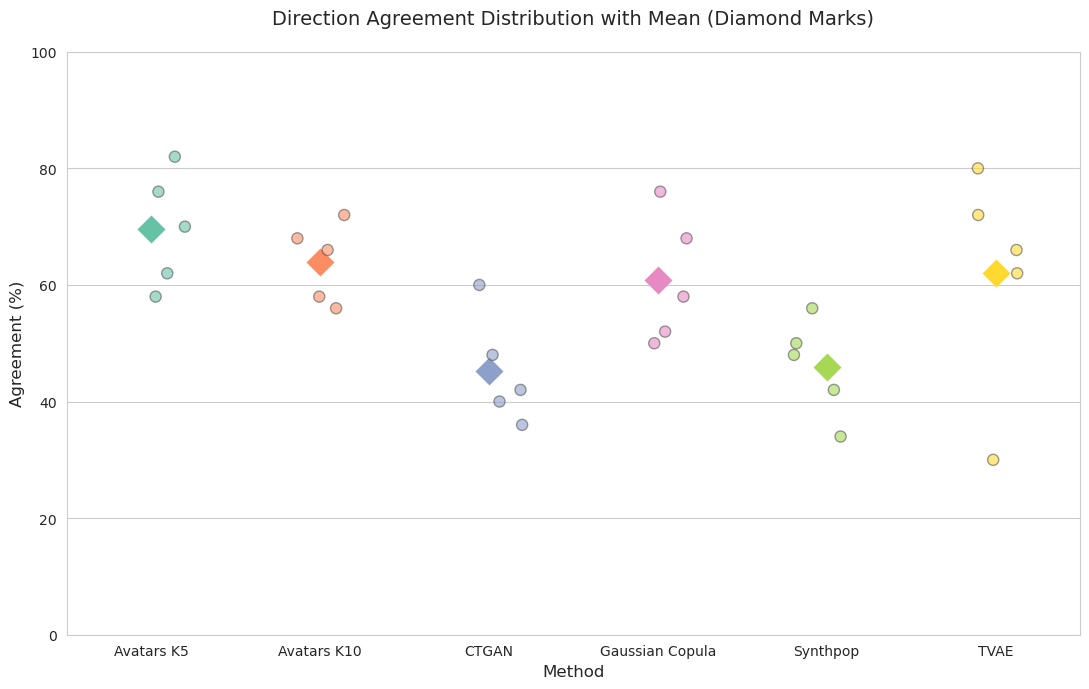

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dữ liệu đầu vào
data = scores_by_tool

DATASET_COLORS = {
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

# 2. Chuyển đổi dữ liệu
df = pd.DataFrame([(k, v) for k, values in data.items() for v in values], 
                  columns=['Dataset', 'Direction Agreement'])

# 3. Vẽ biểu đồ
plt.figure(figsize=(11, 7))
sns.set_style("whitegrid")

# Vẽ Stripplot (các điểm dữ liệu gốc)
sns.stripplot(
    data=df, 
    x='Dataset', 
    y='Direction Agreement', 
    palette=DATASET_COLORS, 
    hue='Dataset',
    jitter=0.2, 
    size=8, 
    alpha=0.6,      # Làm mờ các điểm gốc một chút để nổi bật điểm Mean
    linewidth=1,
    edgecolor='gray',
    legend=False
)

# Vẽ Pointplot để hiển thị giá trị Mean dưới dạng Diamond
sns.pointplot(
    data=df, 
    x='Dataset', 
    y='Direction Agreement', 
    estimator='mean',     # Tính giá trị trung bình
    errorbar=None,        # Không vẽ thanh sai số (error bars)
    markers='D',          # 'D' là ký hiệu cho hình Kim cương (Diamond)
    markersize=12,        # Kích thước kim cương lớn hơn để dễ nhìn
    palette=DATASET_COLORS, 
    hue='Dataset',
    join=False            # Không nối các điểm trung bình lại với nhau
)

# 4. Tinh chỉnh tiêu đề và trục
plt.title('Direction Agreement Distribution with Mean (Diamond Marks)', fontsize=14, pad=20)
plt.ylabel('Agreement (%)', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()